In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import random
from scipy.sparse import csr_matrix, csc_matrix
from scipy.io import mmread
from scipy.stats import mannwhitneyu

In [2]:
sc.logging.print_header()
sc.settings.set_figure_params(dpi_save=600, facecolor='white', fontsize=7, format='pdf')

scanpy==1.10.3 anndata==0.10.9 umap==0.5.7 numpy==1.26.4 scipy==1.11.4 pandas==2.2.3 scikit-learn==1.5.2 statsmodels==0.14.4 igraph==0.11.8 louvain==0.8.1 pynndescent==0.5.13


In [3]:
random.seed(71444)

In [4]:
ad.logging.print_memory_usage()

Memory usage: current 0.52 GB, difference +0.52 GB


In [5]:
outdir = '/cluster/home/chenyulong/GSE265972/out'
os.chdir(outdir)

In [34]:
adata_ref=sc.read_h5ad("/cluster/home/chenyulong/GSE165816/0.1out/cellchat.h5ad")

In [35]:
adata=sc.read_h5ad('./normalization.h5ad')

In [36]:
var_names = adata_ref.var_names.intersection(adata.var_names)
adata_ref = adata_ref[:, var_names].copy()
adata = adata[:, var_names].copy()

In [37]:
sc.tl.ingest(adata, adata_ref, obs=['leiden', 'celltype'])

/cluster/home/chenyulong/.local/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


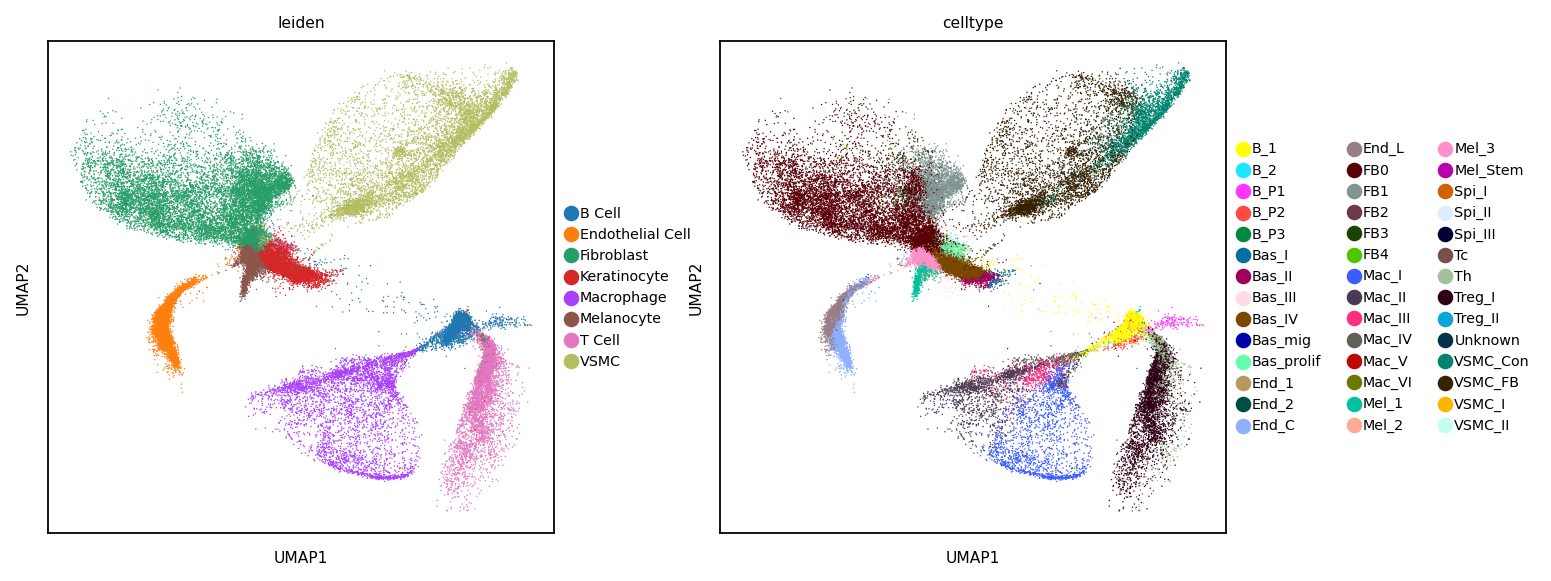

In [38]:
sc.pl.umap(adata, color=['leiden', 'celltype'])

In [39]:
print(adata.X.shape)

(71802, 1439)


In [40]:
group = []
for x in list(adata.obs['sample']):
    if x in ['NS23', 'NS24', 'NS36', 'NS62E', 'NS63D']:
        group.append('control')
    elif x in ['VU1', 'VU4','VU5', 'VU6']:
        group.append('VU')
    else:
        group.append('Unknown')  

adata.obs['group'] = np.array(group)

In [41]:
adata.obs

,sample,doublet_score,predicted_doublet,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,celltype,group
AAACCCAAGACTCTAC-1,VU1,0.075298,False,4415,4415,23933.0,279.0,1.165754,Fibroblast,FB1,VU
AAACCCAAGTGCCGAA-1,VU1,0.038900,False,2042,2042,5697.0,342.0,6.003160,Fibroblast,FB0,VU
AAACCCACAAATACGA-1,VU1,0.064423,False,1265,1265,2960.0,580.0,19.594595,Macrophage,Mac_I,VU
AAACCCACAACGATCT-1,VU1,0.039262,False,4701,4701,27564.0,556.0,2.017124,Fibroblast,FB1,VU
AAACCCACACAGTATC-1,VU1,0.034837,False,2043,2043,5910.0,148.0,2.504230,VSMC,VSMC_FB,VU
...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTACAGAAT-1,NS62E,0.026341,False,1370,1370,3021.0,334.0,11.055942,Melanocyte,Mel_3,control
TTTGTTGGTAGAGACC-1,NS62E,0.078897,False,3267,3267,12211.0,511.0,4.184752,Melanocyte,Mel_3,control
TTTGTTGGTAGAGGAA-1,NS62E,0.014126,False,1827,1827,4779.0,104.0,2.176188,Melanocyte,FB0,control
TTTGTTGTCACTCGAA-1,NS62E,0.132049,False,4031,4031,13372.0,245.0,1.832187,Fibroblast,FB0,control


In [42]:
cell_counts = adata.obs['sample'].value_counts().sort_index()

cell_counts_df = cell_counts.reset_index()
cell_counts_df.columns = ['sample', 'cell_count']

print(cell_counts_df)

  sample  cell_count
0   NS23        6071
1   NS24        6106
2   NS36        7613
3  NS62E        6695
4  NS63D       14596
5    VU1        9251
6    VU4        9839
7    VU5        4409
8    VU6        7222


In [43]:
fb_labels = ['FB0', 'FB1', 'FB2', 'FB3', 'FB4']
fb_data = adata.obs[adata.obs['celltype'].isin(fb_labels)]

cell_counts_df = fb_data.groupby(['sample', 'celltype']).size().unstack(fill_value=0)

cell_counts_df = cell_counts_df[fb_labels]

cell_counts_df = cell_counts_df.reset_index()

print(cell_counts_df)

celltype sample   FB0   FB1  FB2  FB3  FB4
0          NS23  2453    22    0    1    0
1          NS24  1214     8   12   44    8
2          NS36  2107     0    0    4    0
3         NS62E  3514     4    0    0    2
4         NS63D  4078     0    0    0    0
5           VU1   692   463    1  194    3
6           VU4  1585    20    0   11    0
7           VU5   402   862    0    1    0
8           VU6  1636  1338    0  100    8


/tmp/ipykernel_285626/3567117720.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts_df = fb_data.groupby(['sample', 'celltype']).size().unstack(fill_value=0)


In [44]:
adata.write('./Final.h5ad')

In [45]:
adata_ann=sc.read_h5ad("./Final.h5ad")

In [46]:
adata_qc=sc.read_h5ad("./QC.h5ad")

In [47]:
print(adata_qc.shape)
print(adata_ann.shape)

(71802, 29763)
(71802, 1439)


In [48]:
adata=adata_qc[adata_ann.obs['leiden'].isin(['Fibroblast'])]

In [49]:
adata

View of AnnData object with n_obs × n_vars = 19188 × 29763
    obs: 'sample', 'doublet_score', 'predicted_doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'sample_colors', 'scrublet'

In [50]:
adata.write('./Fib.h5ad') 

In [6]:
adata=sc.read_h5ad('./Fib.h5ad')

In [7]:
sc.pp.normalize_total(adata) 
sc.pp.log1p(adata) 

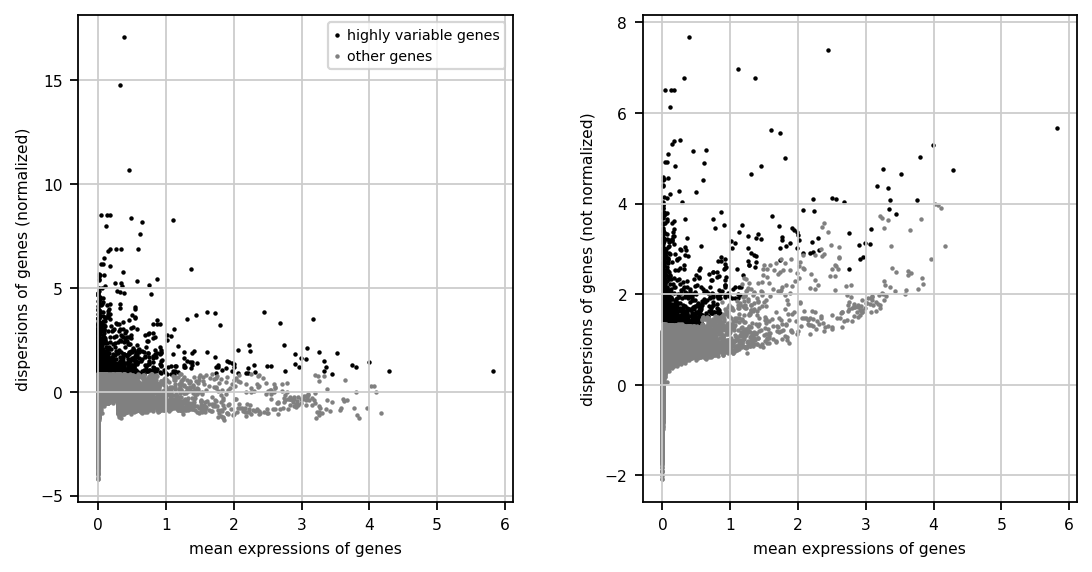

In [8]:
sc.pp.highly_variable_genes(adata, n_top_genes=4000)
sc.pl.highly_variable_genes(adata)

In [9]:
adata.raw = adata 
adata = adata[:, adata.var.highly_variable] 

In [10]:
%%time
sc.pp.scale(adata, max_value=10)

/cluster/home/chenyulong/.local/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


CPU times: user 1.18 s, sys: 440 ms, total: 1.62 s
Wall time: 1.26 s


In [11]:
adata_ref=sc.read_h5ad("/cluster/home/chenyulong/GSE165816/0.1out/Final_Fib.h5ad")

/cluster/home/chenyulong/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [12]:
var_names = adata_ref.var_names.intersection(adata.var_names)
adata_ref = adata_ref[:, var_names].copy()
adata = adata[:, var_names].copy()

In [13]:
sc.tl.ingest(adata, adata_ref, obs=['leiden', 'celltype'])

/cluster/home/chenyulong/.local/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


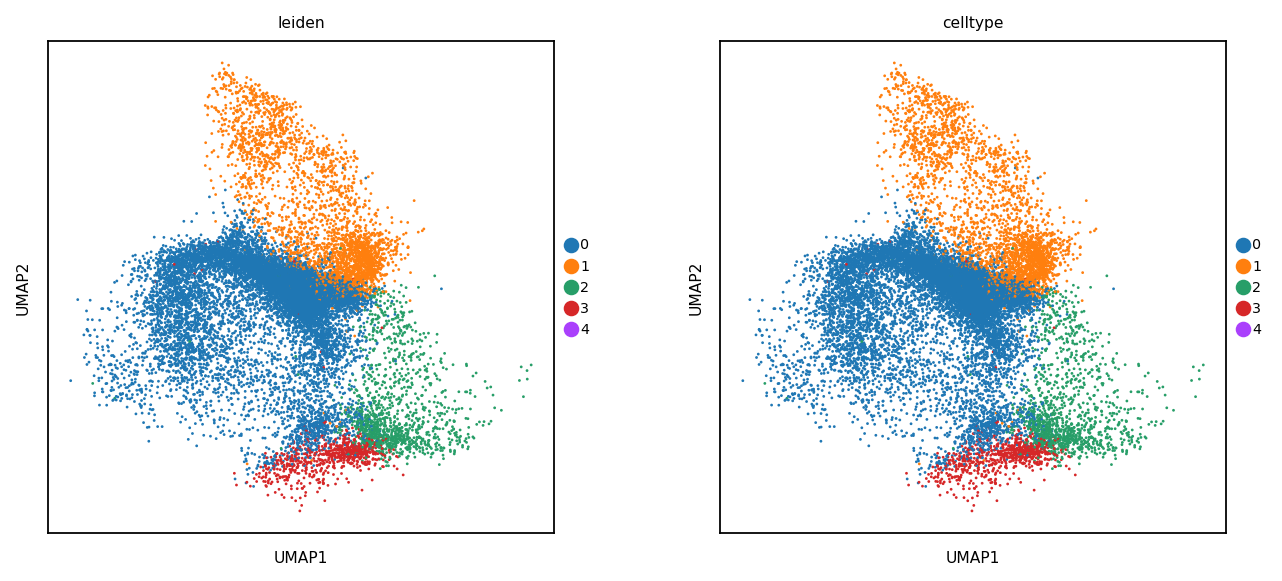

In [14]:
sc.pl.umap(adata, color=['leiden', 'celltype'])

In [15]:
print(adata.X.shape)

(19188, 934)


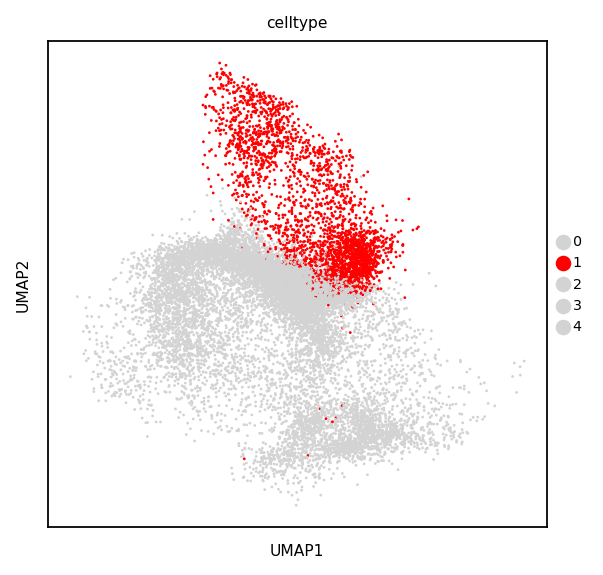

In [16]:
sc.pl.umap(adata, color='celltype', palette={
    "1": "#FF0000",     
    "0": "#D3D3D3",      
    "2": "#D3D3D3",
    "3": "#D3D3D3",
    "4": "#D3D3D3"
}, save='.total:FB1 vs other.pdf')

In [17]:
group = []
for x in list(adata.obs['sample']):
    if x in ['NS23', 'NS24', 'NS36', 'NS62E', 'NS63D']:
        group.append('control')
    elif x in ['VU1', 'VU4','VU5', 'VU6']:
        group.append('VU')
    else:
        group.append('Unknown')  

adata.obs['group'] = np.array(group)

In [18]:
adata.obs

,sample,doublet_score,predicted_doublet,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,celltype,group
AAACCCAAGACTCTAC-1,VU1,0.075298,False,4415,4415,23933.0,279.0,1.165754,1,1,VU
AAACCCAAGTGCCGAA-1,VU1,0.038900,False,2042,2042,5697.0,342.0,6.003160,0,0,VU
AAACCCACAACGATCT-1,VU1,0.039262,False,4701,4701,27564.0,556.0,2.017124,0,0,VU
AAACCCAGTTTCACTT-1,VU1,0.035805,False,1902,1902,5241.0,508.0,9.692807,2,2,VU
AAACCCATCCGTGCGA-1,VU1,0.048393,False,3640,3640,13629.0,302.0,2.215863,0,0,VU
...,...,...,...,...,...,...,...,...,...,...,...
TTTGGTTCAGGAGGTT-1,NS62E,0.019355,False,1289,1289,2703.0,78.0,2.885683,2,2,control
TTTGGTTGTAACACCT-1,NS62E,0.031246,False,1377,1377,3280.0,46.0,1.402439,0,0,control
TTTGTTGAGGTTACCT-1,NS62E,0.100143,False,3502,3502,11853.0,522.0,4.403948,0,0,control
TTTGTTGTCACTCGAA-1,NS62E,0.132049,False,4031,4031,13372.0,245.0,1.832187,0,0,control


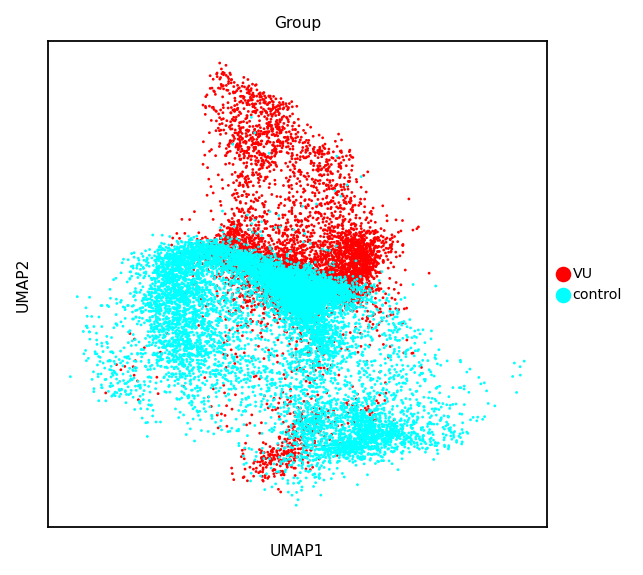

In [19]:
sc.pl.umap(adata, color=['group'],title='Group',palette={
        "VU": "#FF0000FF",
      "control": "#00FFFFFF"}) 

In [20]:
adata.obs['control_FB1_vs_other'] = adata.obs.apply(
    lambda x: '1' if (x['group'] == 'control' and x['celltype'] == '1') else 'other_control', axis=1)

adata.obs['VU_FB1_vs_other'] = adata.obs.apply(
    lambda x: '1' if (x['group'] == 'VU' and x['celltype'] == '1') else 'other_VU', axis=1)

/cluster/home/chenyulong/.local/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


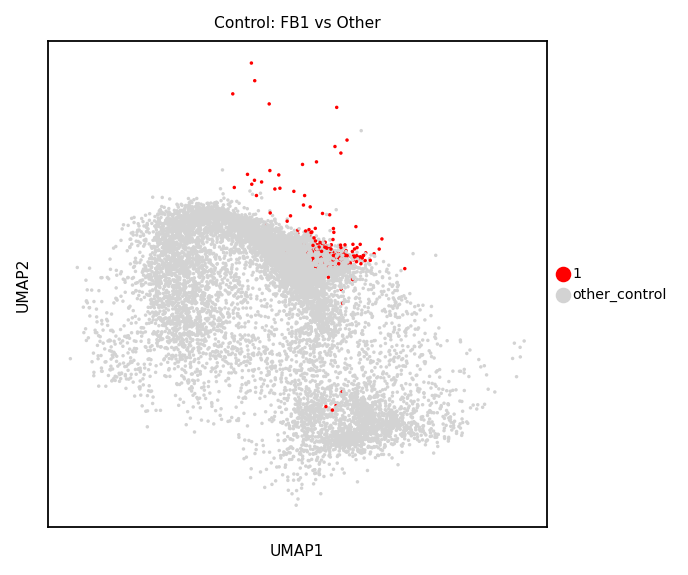

/cluster/home/chenyulong/.local/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


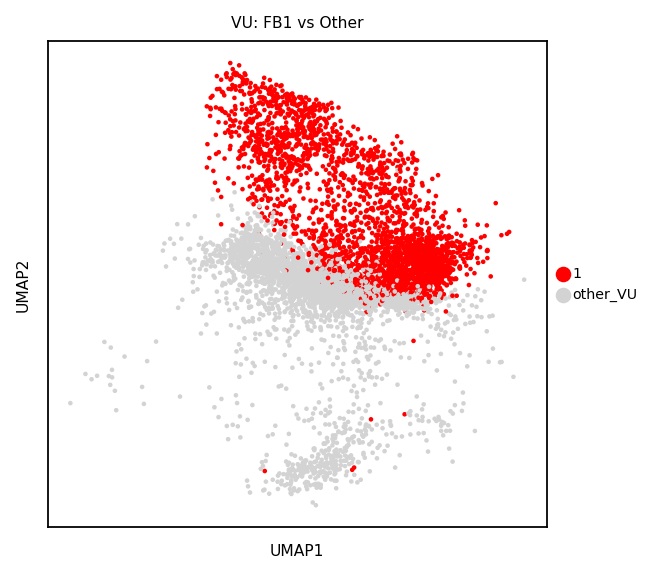

In [22]:
adata_control = adata[adata.obs['group'] == 'control', :]

sc.pl.umap(
    adata_control,
    color='control_FB1_vs_other',
    palette={
        '1': '#FF0000',
        'other_control': '#D3D3D3'
    },
    title='Control: FB1 vs Other',
    save='.Control_FB1_vs_Other.pdf'
)

adata_vu = adata[adata.obs['group'] == 'VU', :]

sc.pl.umap(
    adata_vu,
    color='VU_FB1_vs_other',
    palette={
        '1': '#FF0000',
        'other_VU': '#D3D3D3'
    },
    title='VU: FB1 vs Other',
    save='.VU_FB1_vs_Other.pdf'
)

In [23]:
count_table = pd.crosstab(adata.obs['celltype'], adata.obs['group'])

percent_table = count_table.div(count_table.sum(axis=0), axis=1) * 100

combined_table = pd.concat(
    [count_table.add_suffix('_count'), percent_table.round(2).add_suffix('_percent')],
    axis=1
)

print(combined_table)

group     VU_count  control_count  VU_percent  control_percent
celltype                                                      
0             3617          10230       51.56            84.04
1             3090            214       44.05             1.76
2              112           1139        1.60             9.36
3              196            590        2.79             4.85


In [24]:
count_table = pd.crosstab(adata.obs['celltype'], adata.obs['sample'])

percent_table = count_table.div(count_table.sum(axis=0), axis=1) * 100

combined_table = pd.concat(
    [count_table.add_suffix('_count'), percent_table.round(2).add_suffix('_percent')],
    axis=1
)

print(combined_table)

sample    NS23_count  NS24_count  NS36_count  NS62E_count  NS63D_count  \
celltype                                                                 
0               2071         780        1373         2854         3152   
1                 31          73          56           20           34   
2                125         220         252          342          200   
3                181          79         162           99           69   

sample    VU1_count  VU4_count  VU5_count  VU6_count  NS23_percent  \
celltype                                                             
0               844       1152        320       1301         86.00   
1               402        239        876       1573          1.29   
2                51         43          1         17          5.19   
3                38         19          2        137          7.52   

sample    NS24_percent  NS36_percent  NS62E_percent  NS63D_percent  \
celltype                                                        

Removed empty categories: ['4']
Using categories: ['0', '1', '2', '3']
Color dictionary: {'0': '#fb6095', '1': '#fb878e', '2': '#fbaf87', '3': '#fbd680'}


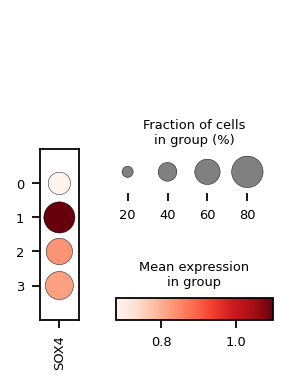

In [26]:
adata.obs['celltype'] = adata.obs['celltype'].astype('category')

empty_cats = [cat for cat in adata.obs['celltype'].cat.categories if cat not in adata.obs['celltype'].unique()]
if empty_cats:
    adata.obs['celltype'] = adata.obs['celltype'].cat.remove_categories(empty_cats)
    print(f"Removed empty categories: {empty_cats}")
else:
    print("No empty categories to remove.")

colors_palette = ['#fb6095', '#fb878e', '#fbaf87', '#fbd680', '#fbfd79']
categories = list(adata.obs['celltype'].cat.categories)
color_dict = {cat: colors_palette[i % len(colors_palette)] for i, cat in enumerate(categories)}

print(f"Using categories: {categories}")
print(f"Color dictionary: {color_dict}")

sc.pl.dotplot(
    adata,
    var_names=['SOX4'],         
    groupby='celltype',
    categories_order=categories,
    use_raw=True,
    save='.sox4experssion.pdf',
    show=True
)

In [27]:
from scipy.stats import mannwhitneyu

gene = 'SOX4'
group_key = 'celltype'
ref_group = '1' 

X = adata.raw[:, gene].X
X = X.toarray().flatten() if hasattr(X, 'toarray') else X.flatten()

df = pd.DataFrame({
    'expression': X,
    'cluster': adata.obs[group_key].astype(str).values
})

clusters = ['0','1','2','3']
df = df[df['cluster'].isin(clusters)]

ref_values = df[df['cluster'] == ref_group]['expression']

pvals = {}

for cl in clusters:
    if cl == ref_group:
        continue
    comp_values = df[df['cluster'] == cl]['expression']
    stat, p = mannwhitneyu(ref_values, comp_values, alternative='two-sided')
    pvals[f'{ref_group} vs {cl}'] = p

for comparison, p in pvals.items():
    print(f"{comparison}: p-value = {p:.4e}")

1 vs 0: p-value = 2.6880e-177
1 vs 2: p-value = 5.8249e-22
1 vs 3: p-value = 3.9277e-17


/tmp/ipykernel_86563/1058172158.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_86563/1058172158.py:24: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


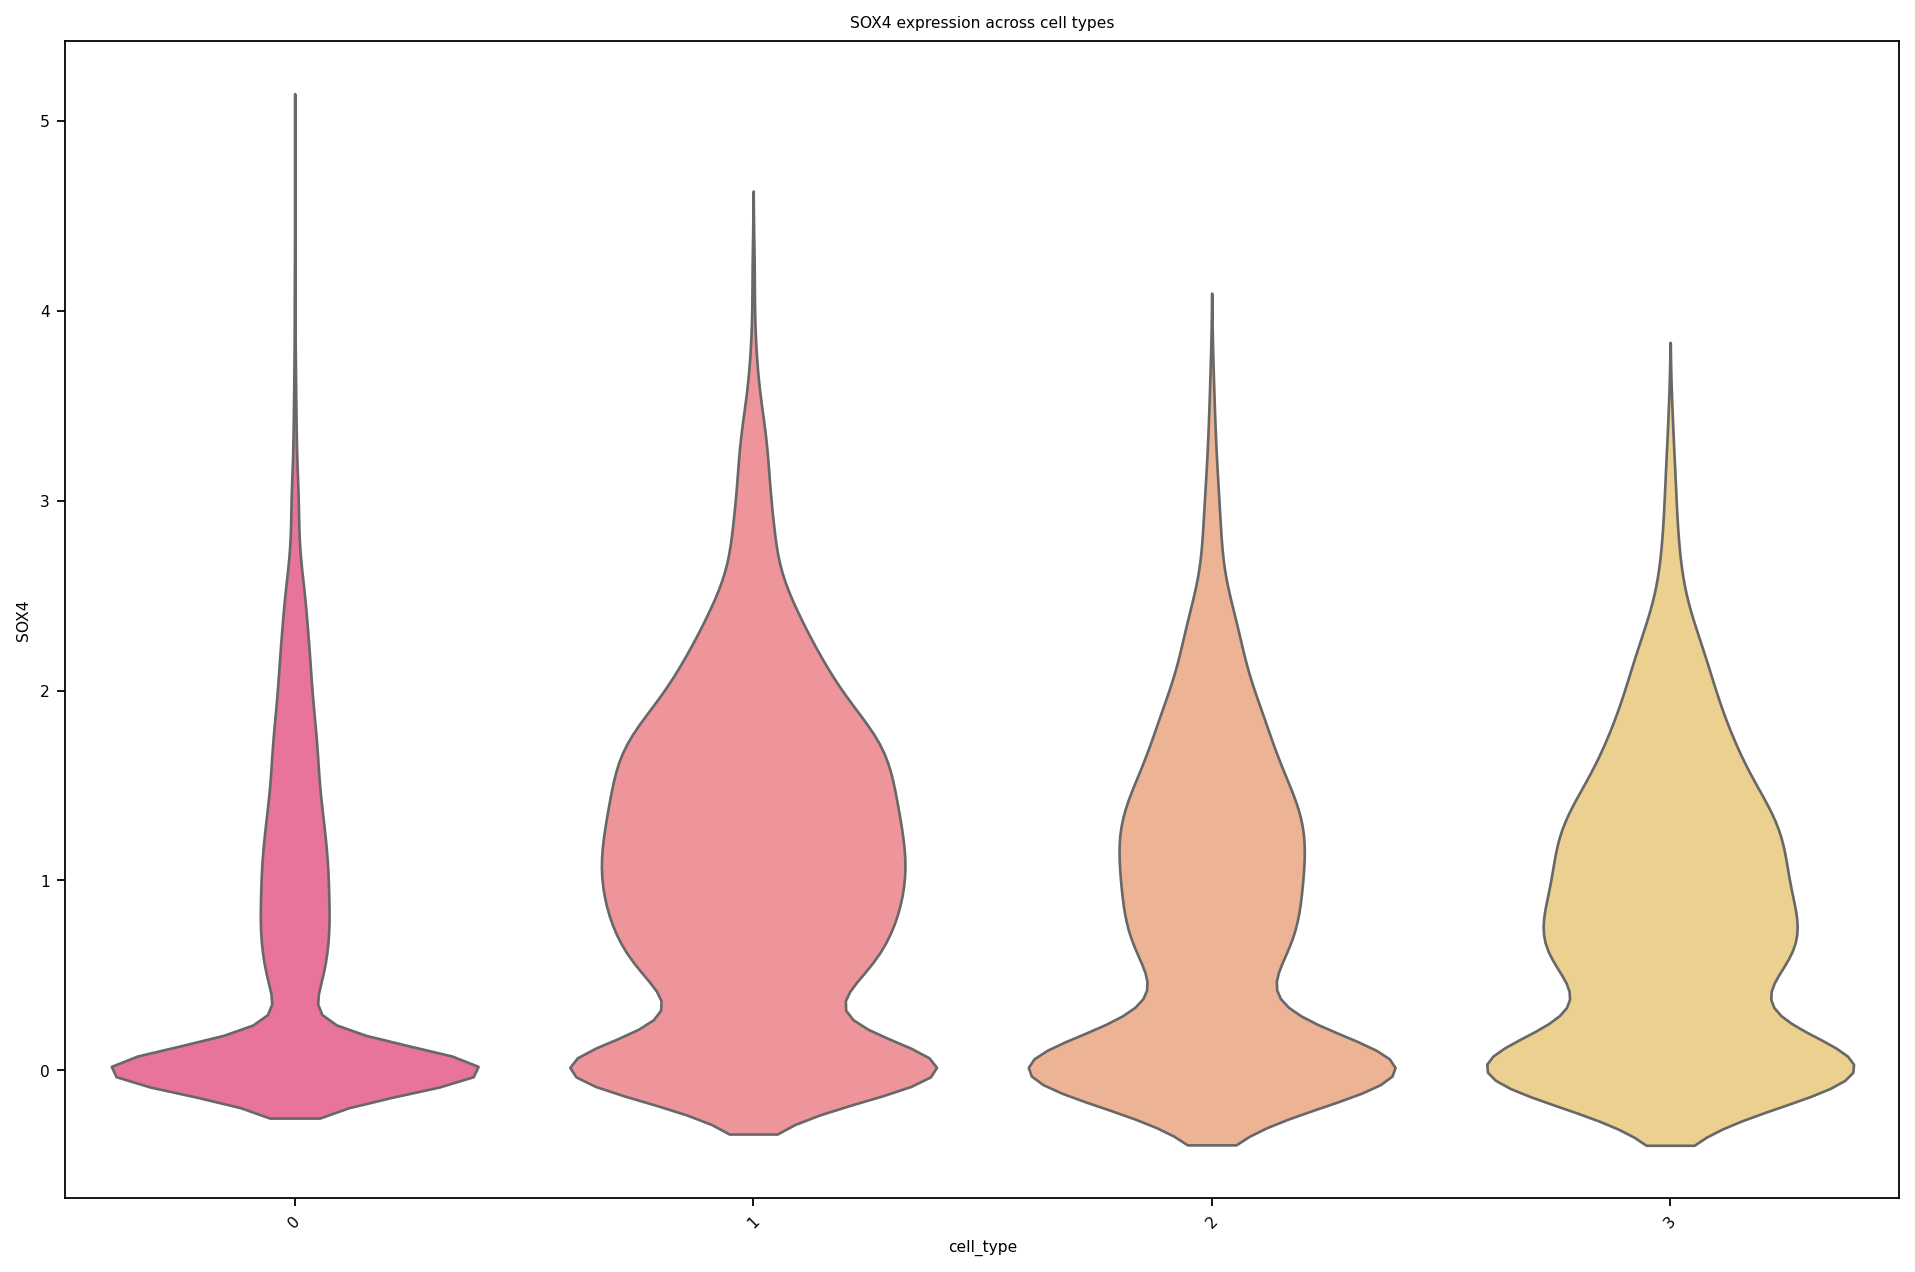

In [28]:
gene = 'SOX4'
celltype_key = 'celltype'  

X = adata.raw[:, gene].X
X = X.toarray().flatten() if hasattr(X, 'toarray') else X.flatten()

df = pd.DataFrame({
    gene: X,
    'cell_type': adata.obs[celltype_key].values
})

celltype_colors = {
    '0': '#fb6095',
    '1': '#fb878e',
    '2': '#fbaf87',
    '3': '#fbd680',
    '4': '#fbfd79'
}

plt.figure(figsize=(12, 8))
sns.violinplot(
    data=df,
    x='cell_type',
    y=gene,
    palette=celltype_colors,
    inner=None,
    linewidth=1.2,
    scale='width'
)
plt.xticks(rotation=45)
plt.grid(False)
plt.title(f'{gene} expression across cell types')
plt.tight_layout()
plt.savefig("SOX4.expression.pdf", format="pdf", bbox_inches="tight")
plt.show()

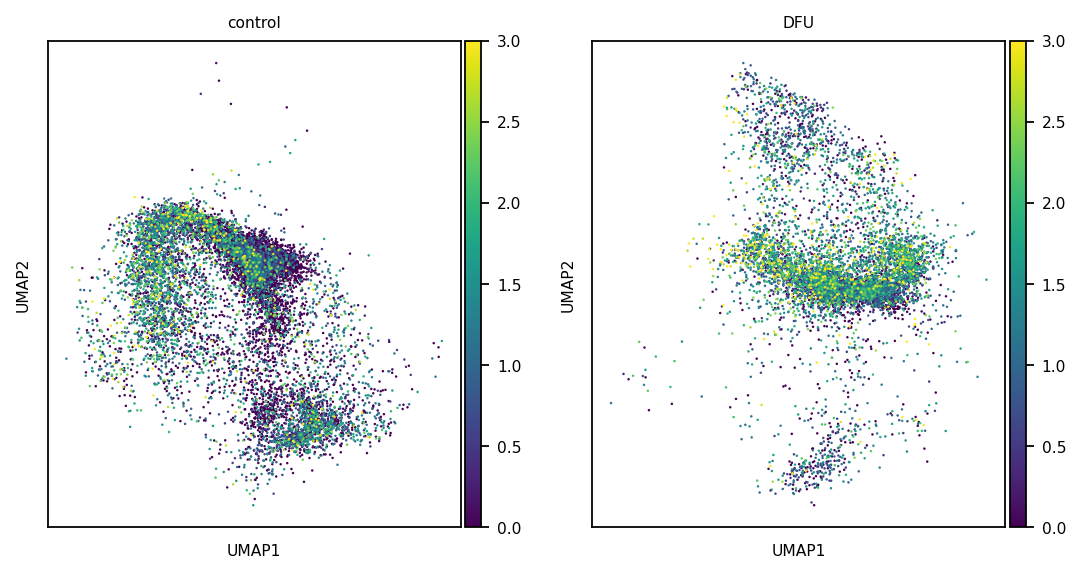

In [29]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

sc.pl.umap(
    adata[adata.obs['group'] == 'control'],
    color=['SOX4'],
    title="control",
    ax=axs[0],
    vmax=3,
    show=False,
    size=5
)

sc.pl.umap(
    adata[adata.obs['group'] == 'VU'],
    color=['SOX4'],
    title="DFU",
    ax=axs[1],
    vmax=3,
    show=False,
    size=5
)

plt.savefig("SOX4.COMPARISON.pdf", format="pdf", bbox_inches="tight")

plt.show()

/tmp/ipykernel_197876/424411028.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


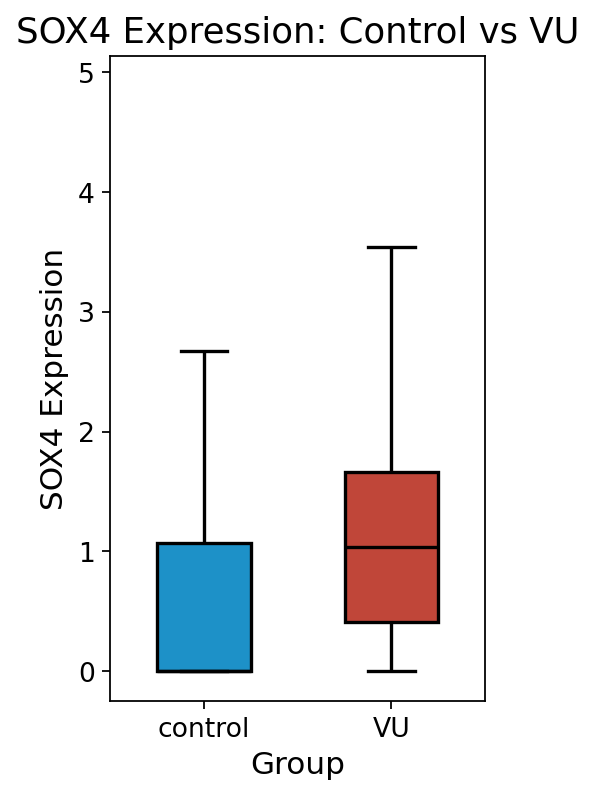

In [21]:
adata.obs['SOX4_expr'] = adata.raw[:, 'SOX4'].X.toarray().flatten()

adata_df = adata.obs

group1_data = adata_df[adata_df['group'] == 'control']['SOX4_expr'].dropna()
group2_data = adata_df[adata_df['group'] == 'VU']['SOX4_expr'].dropna()

if group1_data.empty or group2_data.empty:
    print("One of the groups is empty. Please check the group values or data availability.")
else:
   
    plt.figure(figsize=(3, 5))
    sns.boxplot(
        x='group',
        y='SOX4_expr',
        data=adata_df[adata_df['group'].isin(['control', 'VU'])],
        width=0.5,
        fliersize=0,
        linewidth=0.8,
        order=['control', 'VU'],
        palette={'control': '#009CE4', 'VU': '#D63423'},
        boxprops=dict(edgecolor='black', linewidth=1.5),
        whiskerprops=dict(color='black', linewidth=1.5),
        capprops=dict(color='black', linewidth=1.5),
        medianprops=dict(color='black', linewidth=1.5)
    )

    plt.title("SOX4 Expression: Control vs VU", fontsize=16)
    plt.xlabel("Group", fontsize=14)
    plt.ylabel("SOX4 Expression", fontsize=14)

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    
    # plt.ylim(0, 5)

    plt.grid(False)
    plt.tight_layout()

  
    plt.savefig("SOX4_expression_control_vs_VU.pdf", dpi=600, bbox_inches='tight')
    plt.show()

In [31]:
from scipy.stats import mannwhitneyu

gene_name = 'SOX4'  

if gene_name not in adata.raw.var_names:
    raise ValueError(f"{gene_name} 不在 adata.raw.var_names 中，请检查基因名大小写或使用 adata 而非 adata.raw")

gene_expr = adata.raw[:, gene_name].X.toarray().flatten()

groups = adata.obs['group']

expr_control = gene_expr[groups == 'control']
expr_vu = gene_expr[groups == 'VU']

stat, pval = mannwhitneyu(expr_control, expr_vu, alternative='two-sided')

print(f"SOX4 表达在 control vs VU 中的 Mann-Whitney U 检验 p 值为: {pval:.4e}")

SOX4 表达在 control vs VU 中的 Mann-Whitney U 检验 p 值为: 0.0000e+00


In [48]:
adata=sc.read_h5ad('./Final.h5ad')

In [50]:
genes_of_interest = ['TNFRSF1A', 'JAM2', 'CTSB', 'SDC4', 'HLA-E', 'DLL1',  'THY1', 'CSF1', 'IL19', 'ADM', 
                     'ASGR1', 'TNFRSF9', 'CA12', 'BTN2A1', 'CD27', 'DPY30']
print([gene for gene in genes_of_interest if gene in adata.raw.var_names])

['TNFRSF1A', 'JAM2', 'CTSB', 'SDC4', 'HLA-E', 'DLL1', 'THY1', 'CSF1', 'IL19', 'ADM', 'ASGR1', 'TNFRSF9', 'CA12', 'BTN2A1', 'CD27', 'DPY30']


In [51]:
valid_genes = [gene for gene in genes_of_interest if gene in adata.raw.var_names]
adata_subset = adata.raw[:, valid_genes].to_adata()

In [52]:
adata_subset.write("subset_genes.h5ad")

In [53]:
adata_subset.obs = adata.obs
adata_subset.var = adata.raw.var.loc[valid_genes]

In [54]:
adata_loaded = sc.read("subset_genes.h5ad")
print(adata_loaded)

AnnData object with n_obs × n_vars = 71802 × 16
    obs: 'sample', 'doublet_score', 'predicted_doublet', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'celltype', 'group'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'celltype_colors', 'hvg', 'leiden_colors', 'log1p', 'sample_colors', 'scrublet'
    obsm: 'X_pca', 'X_umap', 'rep'


In [55]:
def calculate_signature_per_cell(adata, genes):
    expression_matrix = adata[:, genes].X.toarray() if hasattr(adata.X, "toarray") else adata[:, genes].X
    
    signatures = np.sum(expression_matrix, axis=1)
    return signatures

def analyze_signature_by_celltype(adata, signatures, cell_type_col='celltype'):
    adata.obs['Signature'] = signatures
    
    summary_df = adata.obs.groupby(cell_type_col)['Signature'].agg(['mean', 'median', 'std', 'count']).reset_index()
    summary_df.rename(columns={
        'mean': 'MeanSignature',
        'median': 'MedianSignature',
        'std': 'StdDevSignature',
        'count': 'CellCount'
    }, inplace=True)
    return summary_df

genes_of_interest = ['TNFRSF1A', 'JAM2', 'CTSB', 'SDC4', 'HLA-E', 'DLL1',  'THY1', 'CSF1', 'IL19', 'ADM', 
                     'ASGR1', 'TNFRSF9', 'CA12', 'BTN2A1', 'CD27', 'DPY30']
signatures = calculate_signature_per_cell(adata_loaded, genes_of_interest)
signature_summary = analyze_signature_by_celltype(adata_loaded, signatures)

signatures_with_celltype = pd.DataFrame({'Signature': signatures, 'celltype': adata_loaded.obs['celltype']})
with pd.ExcelWriter("signatures.xlsx") as writer:
    signatures_with_celltype.to_excel(writer, sheet_name='Signatures')

/tmp/ipykernel_86563/851786980.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_df = adata.obs.groupby(cell_type_col)['Signature'].agg(['mean', 'median', 'std', 'count']).reset_index()


In [56]:
genes_of_interest = ['TNFRSF1A', 'JAM2', 'CTSB', 'SDC4', 'HLA-E', 'DLL1',  'THY1', 'CSF1', 'IL19', 'ADM', 
                     'ASGR1', 'TNFRSF9', 'CA12', 'BTN2A1', 'CD27', 'DPY30']
expression_matrix = adata_loaded[:, genes_of_interest].X.toarray() if hasattr(adata_loaded.X, "toarray") else adata_loaded[:, genes_of_interest].X

gene_expression_df = pd.DataFrame(
    expression_matrix,
    columns=genes_of_interest,
    index=adata_loaded.obs.index  
)

gene_expression_df['celltype'] = adata_loaded.obs['celltype'].values

grouped_stats = gene_expression_df.groupby('celltype')[genes_of_interest].agg(['sum', 'mean', 'median', 'std', 'count'])

gene_expression_df['TotalExpression'] = gene_expression_df[genes_of_interest].sum(axis=1)  
total_expression_by_celltype = gene_expression_df.groupby('celltype')['TotalExpression'].sum()  

with pd.ExcelWriter("gene_expression_analysis.xlsx") as writer:
    gene_expression_df.to_excel(writer, sheet_name="GeneExpressionPerCell")  
    grouped_stats.to_excel(writer, sheet_name="GroupedStats")  
    total_expression_by_celltype.to_excel(writer, sheet_name="TotalExpressionByCelltype")  

/tmp/ipykernel_86563/1236119245.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_stats = gene_expression_df.groupby('celltype')[genes_of_interest].agg(['sum', 'mean', 'median', 'std', 'count'])
/tmp/ipykernel_86563/1236119245.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_expression_by_celltype = gene_expression_df.groupby('celltype')['TotalExpression'].sum()  # 每类细胞的总和


/tmp/ipykernel_86563/2412491173.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


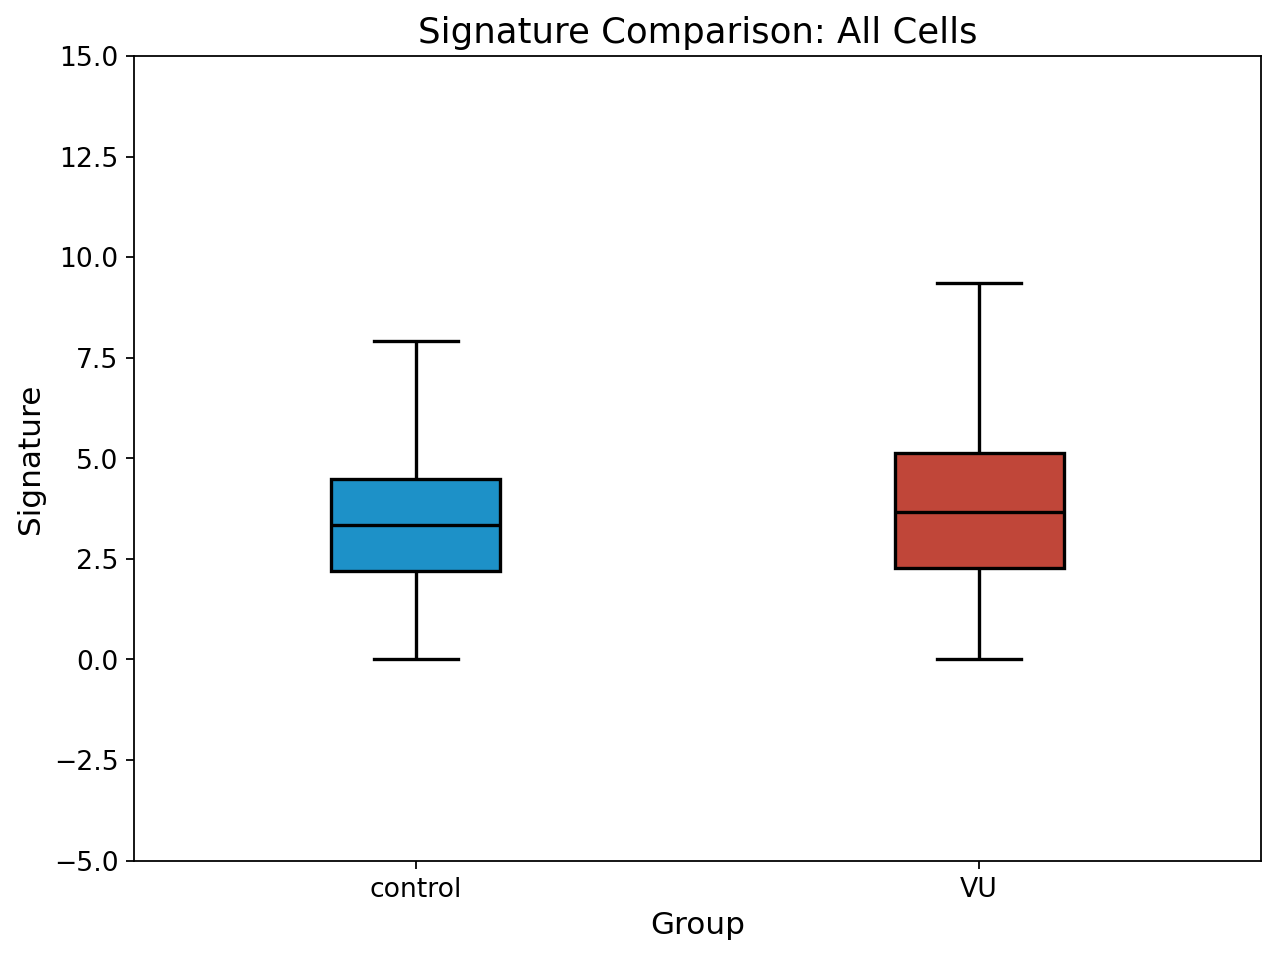

In [57]:
adata_df = adata_loaded.obs

group1_data = adata_df[adata_df['group'] == 'control']['Signature'].dropna()
group2_data = adata_df[adata_df['group'] == 'VU']['Signature'].dropna()


if group1_data.empty or group2_data.empty:
    print("One of the groups is empty. Please check the group values or data availability.")
else:
  
    plt.figure(figsize=(8, 6))
    sns.boxplot(
        x='group',
        y='Signature',
        data=adata_df,
        width=0.3,
        fliersize=0,
        linewidth=0.8,
        order=['control', 'VU'],
        palette={'control': '#009CE4', 'VU': '#D63423'},
        boxprops=dict(edgecolor='black', linewidth=1.5),
        whiskerprops=dict(color='black', linewidth=1.5),
        capprops=dict(color='black', linewidth=1.5),
        medianprops=dict(color='black', linewidth=1.5)
    )

    plt.title("Signature Comparison: All Cells", fontsize=16)
    plt.xlabel("Group", fontsize=14)
    plt.ylabel("Signature", fontsize=14)


    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    plt.ylim(-5, 15)

    plt.grid(False)
    plt.tight_layout()

   
    plt.savefig("signature_all_cells.pdf", dpi=300, bbox_inches='tight')
    plt.show()

In [58]:
control_signature = adata_loaded.obs.query("group == 'control'")['Signature'].dropna()
dfu_signature = adata_loaded.obs.query("group == 'VU'")['Signature'].dropna()

stat, pval = mannwhitneyu(control_signature, dfu_signature, alternative='two-sided')

print(f"Control vs VU Signature 表达的 Mann–Whitney U 检验：")
print(f"统计量 = {stat:.2f}, p 值 = {pval:.4e}")

Control vs VU Signature 表达的 Mann–Whitney U 检验：
统计量 = 564118708.00, p 值 = 5.4910e-131


In [59]:
print(group1_data.describe())
print(group2_data.describe())

count    41081.000000
mean         3.359434
std          1.809368
min          0.000000
25%          2.196805
50%          3.344225
75%          4.482573
max         11.500942
Name: Signature, dtype: float64
count    30721.000000
mean         3.807236
std          2.178890
min          0.000000
25%          2.282961
50%          3.661756
75%          5.118609
max         14.829020
Name: Signature, dtype: float64


In [21]:
genes = [
    'TNFRSF1A', 'BCAN', 'HLA-E', 'IL19', 'CA12', 'JAM2', 'DLL1', 'ADM',
     'BTN2A1', 'CTSB', 'ASGR1', 'CD27', 'SDC4', 'THY1', 'CSF1',
    'TNFRSF9', 'TAFA5'
]

vu = adata[adata.obs['group'] == 'VU'].copy()

def get_expr(adata, gene):
    if gene in adata.var_names:
        x = adata[:, gene].X
    else:
        x = adata.raw[:, gene].X
    return x.toarray().flatten() if hasattr(x, 'toarray') else x.flatten()

summary = []
for g in genes:
    expr = get_expr(vu, g)
    summary.append({'gene': g, 'mean': np.mean(expr), 'std': np.std(expr)})
summary_df = pd.DataFrame(summary)
print(summary_df.round(3))
summary_df['mean±std'] = summary_df.apply(
    lambda row: f"{row['mean']:.3f}±{row['std']:.3f}", axis=1
)

out = summary_df[['gene', 'mean±std']]

out.to_csv('VU_16genes_mean±std.csv', index=False)

print(out)

        gene   mean    std
0   TNFRSF1A  0.342  0.401
1       BCAN -0.032  0.569
2      HLA-E  1.114  0.693
3       IL19  0.021  0.118
4       CA12  0.574  0.682
5       JAM2  0.093  0.229
6       DLL1  0.071  0.221
7        ADM  0.408  1.184
8     BTN2A1  0.095  0.241
9       CTSB  0.959  0.642
10     ASGR1  0.009  0.076
11      CD27  0.007  0.082
12      SDC4 -0.180  0.787
13      THY1  1.159  0.977
14      CSF1  0.102  0.266
15   TNFRSF9  0.012  0.102
16     TAFA5  0.025  0.125
        gene      mean±std
0   TNFRSF1A   0.342±0.401
1       BCAN  -0.032±0.569
2      HLA-E   1.114±0.693
3       IL19   0.021±0.118
4       CA12   0.574±0.682
5       JAM2   0.093±0.229
6       DLL1   0.071±0.221
7        ADM   0.408±1.184
8     BTN2A1   0.095±0.241
9       CTSB   0.959±0.642
10     ASGR1   0.009±0.076
11      CD27   0.007±0.082
12      SDC4  -0.180±0.787
13      THY1   1.159±0.977
14      CSF1   0.102±0.266
15   TNFRSF9   0.012±0.102
16     TAFA5   0.025±0.125


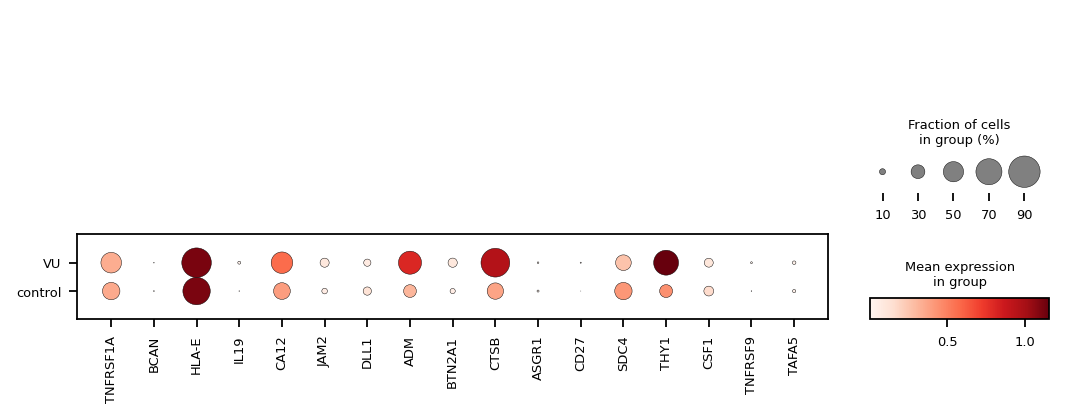

In [ ]:
sc.pl.dotplot(adata,['TNFRSF1A', 'BCAN', 'HLA-E', 'IL19', 'CA12', 'JAM2', 'DLL1', 'ADM',
                     'BTN2A1', 'CTSB', 'ASGR1', 'CD27', 'SDC4', 'THY1', 'CSF1',
                     'TNFRSF9', 'TAFA5'], groupby='group', save='_VU_genes_dotplot.pdf')